# 구글 드라이브 연동

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)

# ── 스타일 설정 ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'NanumBarunGothic',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.unicode_minus': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 110,
})
print("라이브러리 로드 완료")

print("라이브러리 로드 완료")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")


라이브러리 로드 완료
라이브러리 로드 완료
  numpy  2.0.2
  pandas 2.2.2


In [6]:
import pandas as pd

df_pca = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/2022_worldcup.csv").set_index("Unnamed: 0")

df_pca.head()

,xg_pg,xg_per_shot,shot_accuracy_pct,pass_accuracy_pct,passes_pg,key_passes_pg,pressure_pg,carry_final_third_pg,dribble_success_pct,fouls_pg,interceptions_pg,clearances_pg,group
Unnamed: 0,,,,,,,,,,,,,
Canada,1.309542,0.112246,14.285714,83.895608,523.666667,8.333333,126.666667,115.666667,53.333333,12.333333,10.666667,17.000000,F
Morocco,0.593384,0.071206,32.000000,79.893238,374.666667,5.000000,161.000000,62.666667,47.727273,16.333333,12.000000,24.333333,NaN
England,1.787760,0.137520,43.589744,87.414966,686.000000,6.666667,92.666667,124.000000,60.000000,10.333333,7.333333,12.000000,B
Iran,1.276802,0.116073,27.272727,70.400000,375.000000,7.000000,150.666667,70.000000,42.424242,17.333333,15.666667,16.000000,B
Croatia,1.385031,0.143279,51.724138,83.351831,600.666667,6.000000,145.666667,121.666667,45.000000,12.666667,13.666667,17.666667,F


In [3]:
# [2. PCA에 투입할 핵심 변수 12개 리스트업]
# 모델이 각 팀의 전술적 차이를 가장 잘 학습할 수 있도록 대표 지표만 선별합니다.
pca_cols  = ['xg_pg','xg_per_shot','shot_accuracy_pct','pass_accuracy_pct',
             'passes_pg','key_passes_pg','pressure_pg','carry_final_third_pg',
             'dribble_success_pct','fouls_pg','interceptions_pg','clearances_pg']

# 나중에 그래프(Scree Plot, Biplot 등)를 그릴 때 라벨이 겹치지 않도록 짧은 한글 축약어를 준비합니다.
col_short = ['xG/G','xG/Shot','유효슈팅%','패스%','패스/G','키패스/G',
             '압박/G','파이널서드\n진입/G','드리블%','파울/G','인터셉션/G','클리어런스/G']

In [9]:
# PCA 수행 : 공분산행렬 => SVD 특이값 분해 과정
X = df_pca[pca_cols].values

# 표준화 : 서로 다른 단위 통일
mu = X.mean(axis=0) # 각 변수의 평군
sig = X.std(axis=0, ddof=0) # 각 변수의 표준편차
Z = (X -mu) / sig # Z-score 표준화

# 공분산행렬 C = (1/n) Z^T Z
C = Z.T @ Z / len(Z)  # 짝을 찾는 과정, 변수들끼리 얼마나 같이 움직이느냐(커플링) => 행렬로 표시한다

# 특이값 분해
# 맥도날드 50개의 단품 메뉴(원래 변수) 가정
# 친구들과 같이 가면, 세트1(버거 + 콜라), 세트2(치킨너겟 + 맥주)
# 새로운 바구니로 묶어내기
U, S, Vt = np.linalg.svd(C) # 특이값 분해 공식

# 새로운 세트 메뉴가 전체 매출에서 차지하는 중요도 생각
# 고윳값이 크면 클수록 중요하겠죠
# 변수 1개 이상의 정보량을 가지고 있는 유의미한 주성분
evals = S   # 고윳값

# 새로운 세트 메뉴의 구성 비율
# 새로운 세트 메뉴(3가지, 4가지, 5가지)

V     = Vt  # 고유 벡터 (열벡터 = 주성분 방향)
evr   = evals / evals.sum() # 설명 분산 비율
scores = Z @ V  # PC 점수

print("── PCA 결과 ──")
print(f"{'PC':>4} {'고유값λ':>10} {'설명분산':>10} {'누적':>10}")
print("-" * 38)
cumsum = 0
for i, (ev, er) in enumerate(zip(evals, evr)):
    cumsum += er * 100
    bar = '█' * int(er * 100 / 2)
    print(f"  PC{i+1:2d}: λ={ev:.4f}   {er*100:5.1f}%   {cumsum:5.1f}%  {bar}")

print(f"\n공분산행렬 C 검증: shape={C.shape}, 대칭={np.allclose(C, C.T)}")
print(f"고유벡터 직교성 검증: V^T V ≈ I ? {np.allclose(V.T @ V, np.eye(len(pca_cols)), atol=1e-10)}")

── PCA 결과 ──
  PC       고유값λ       설명분산         누적
--------------------------------------
  PC 1: λ=5.1877    43.2%    43.2%  █████████████████████
  PC 2: λ=1.6313    13.6%    56.8%  ██████
  PC 3: λ=1.2378    10.3%    67.1%  █████
  PC 4: λ=1.1294     9.4%    76.6%  ████
  PC 5: λ=0.8874     7.4%    83.9%  ███
  PC 6: λ=0.8046     6.7%    90.7%  ███
  PC 7: λ=0.3953     3.3%    93.9%  █
  PC 8: λ=0.3628     3.0%    97.0%  █
  PC 9: λ=0.2250     1.9%    98.8%  
  PC10: λ=0.0726     0.6%    99.4%  
  PC11: λ=0.0452     0.4%    99.8%  
  PC12: λ=0.0211     0.2%   100.0%  

공분산행렬 C 검증: shape=(12, 12), 대칭=True
고유벡터 직교성 검증: V^T V ≈ I ? True


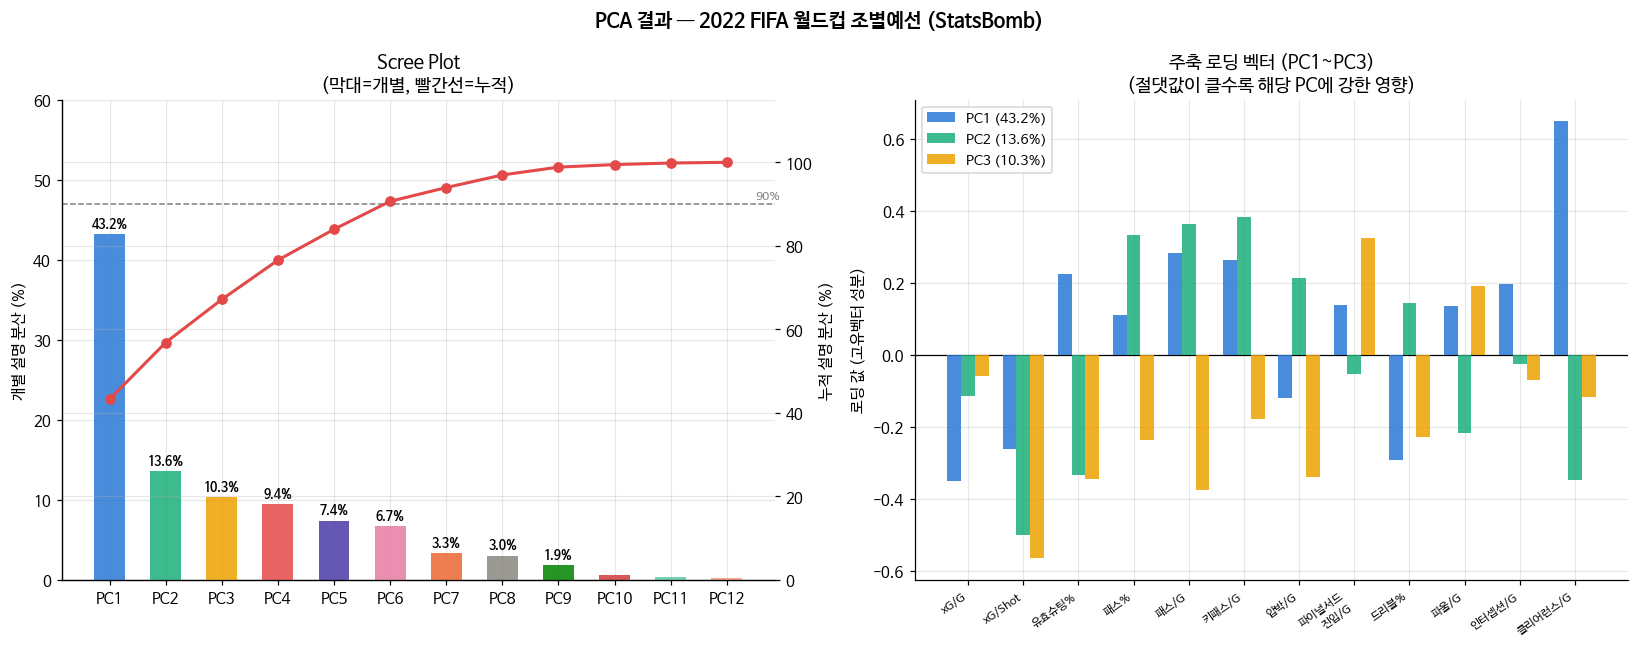

── PC 자동 해석 ──

  PC1 (43.2%)
    강한 양(+): ['클리어런스/G', '패스/G', '키패스/G']
    강한 음(−): ['xG/G', '드리블%', 'xG/Shot']

  PC2 (13.6%)
    강한 양(+): ['키패스/G', '패스/G', '패스%']
    강한 음(−): ['xG/Shot', '클리어런스/G', '유효슈팅%']

  PC3 (10.3%)
    강한 양(+): ['파이널서드\n진입/G', '파울/G', 'xG/G']
    강한 음(−): ['xG/Shot', '패스/G', '유효슈팅%']


In [10]:
# ── Scree Plot + 로딩 벡터 ────────────────────────────────
COLORS = ['#2a78d6','#1baf7a','#eda100','#e34948','#4a3aa7',
          '#e87ba4','#eb6834','#888780','#008300','#d03b3b','#5DCAA5','#F0997B']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('PCA 결과 — 2022 FIFA 월드컵 조별예선 (StatsBomb)',
             fontsize=13, fontweight='bold')

pc_labels = [f'PC{i+1}' for i in range(len(pca_cols))]

# ── Scree Plot ──
ax  = axes[0]
ax2 = ax.twinx()
bars = ax.bar(pc_labels, evr*100, color=COLORS, alpha=0.85, width=0.55, zorder=3)
for bar, v in zip(bars, evr*100):
    if v > 1.5:
        ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.plot(pc_labels, np.cumsum(evr)*100, 'o-', color='#e34948', lw=2, ms=6, zorder=4)
ax2.axhline(90, color='gray', ls='--', lw=1)
ax2.text(len(pca_cols)-0.5, 91, '90%', fontsize=8, color='gray')
ax2.set_ylim(0, 115); ax2.set_ylabel('누적 설명 분산 (%)')
ax.set_ylabel('개별 설명 분산 (%)'); ax.set_ylim(0, 60)
ax.set_title('Scree Plot\n(막대=개별, 빨간선=누적)'); ax.grid(axis='y', alpha=0.3)

# ── 로딩 벡터 ──
ax = axes[1]
xp = np.arange(len(pca_cols)); w = 0.25
for k in range(3):
    ax.bar(xp + k*w, V[:,k], width=w, color=COLORS[k], alpha=0.85,
           label=f'PC{k+1} ({evr[k]*100:.1f}%)', zorder=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xp+w); ax.set_xticklabels(col_short, fontsize=7.5, rotation=35, ha='right')
ax.set_ylabel('로딩 값 (고유벡터 성분)')
ax.set_title('주축 로딩 벡터 (PC1~PC3)\n(절댓값이 클수록 해당 PC에 강한 영향)')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# PC 해석 자동 출력
print("── PC 자동 해석 ──")
for k in range(3):
    top3_pos = np.argsort(V[:,k])[::-1][:3]
    top3_neg = np.argsort(V[:,k])[:3]
    print(f"\n  PC{k+1} ({evr[k]*100:.1f}%)")
    print(f"    강한 양(+): {[col_short[i] for i in top3_pos]}")
    print(f"    강한 음(−): {[col_short[i] for i in top3_neg]}")


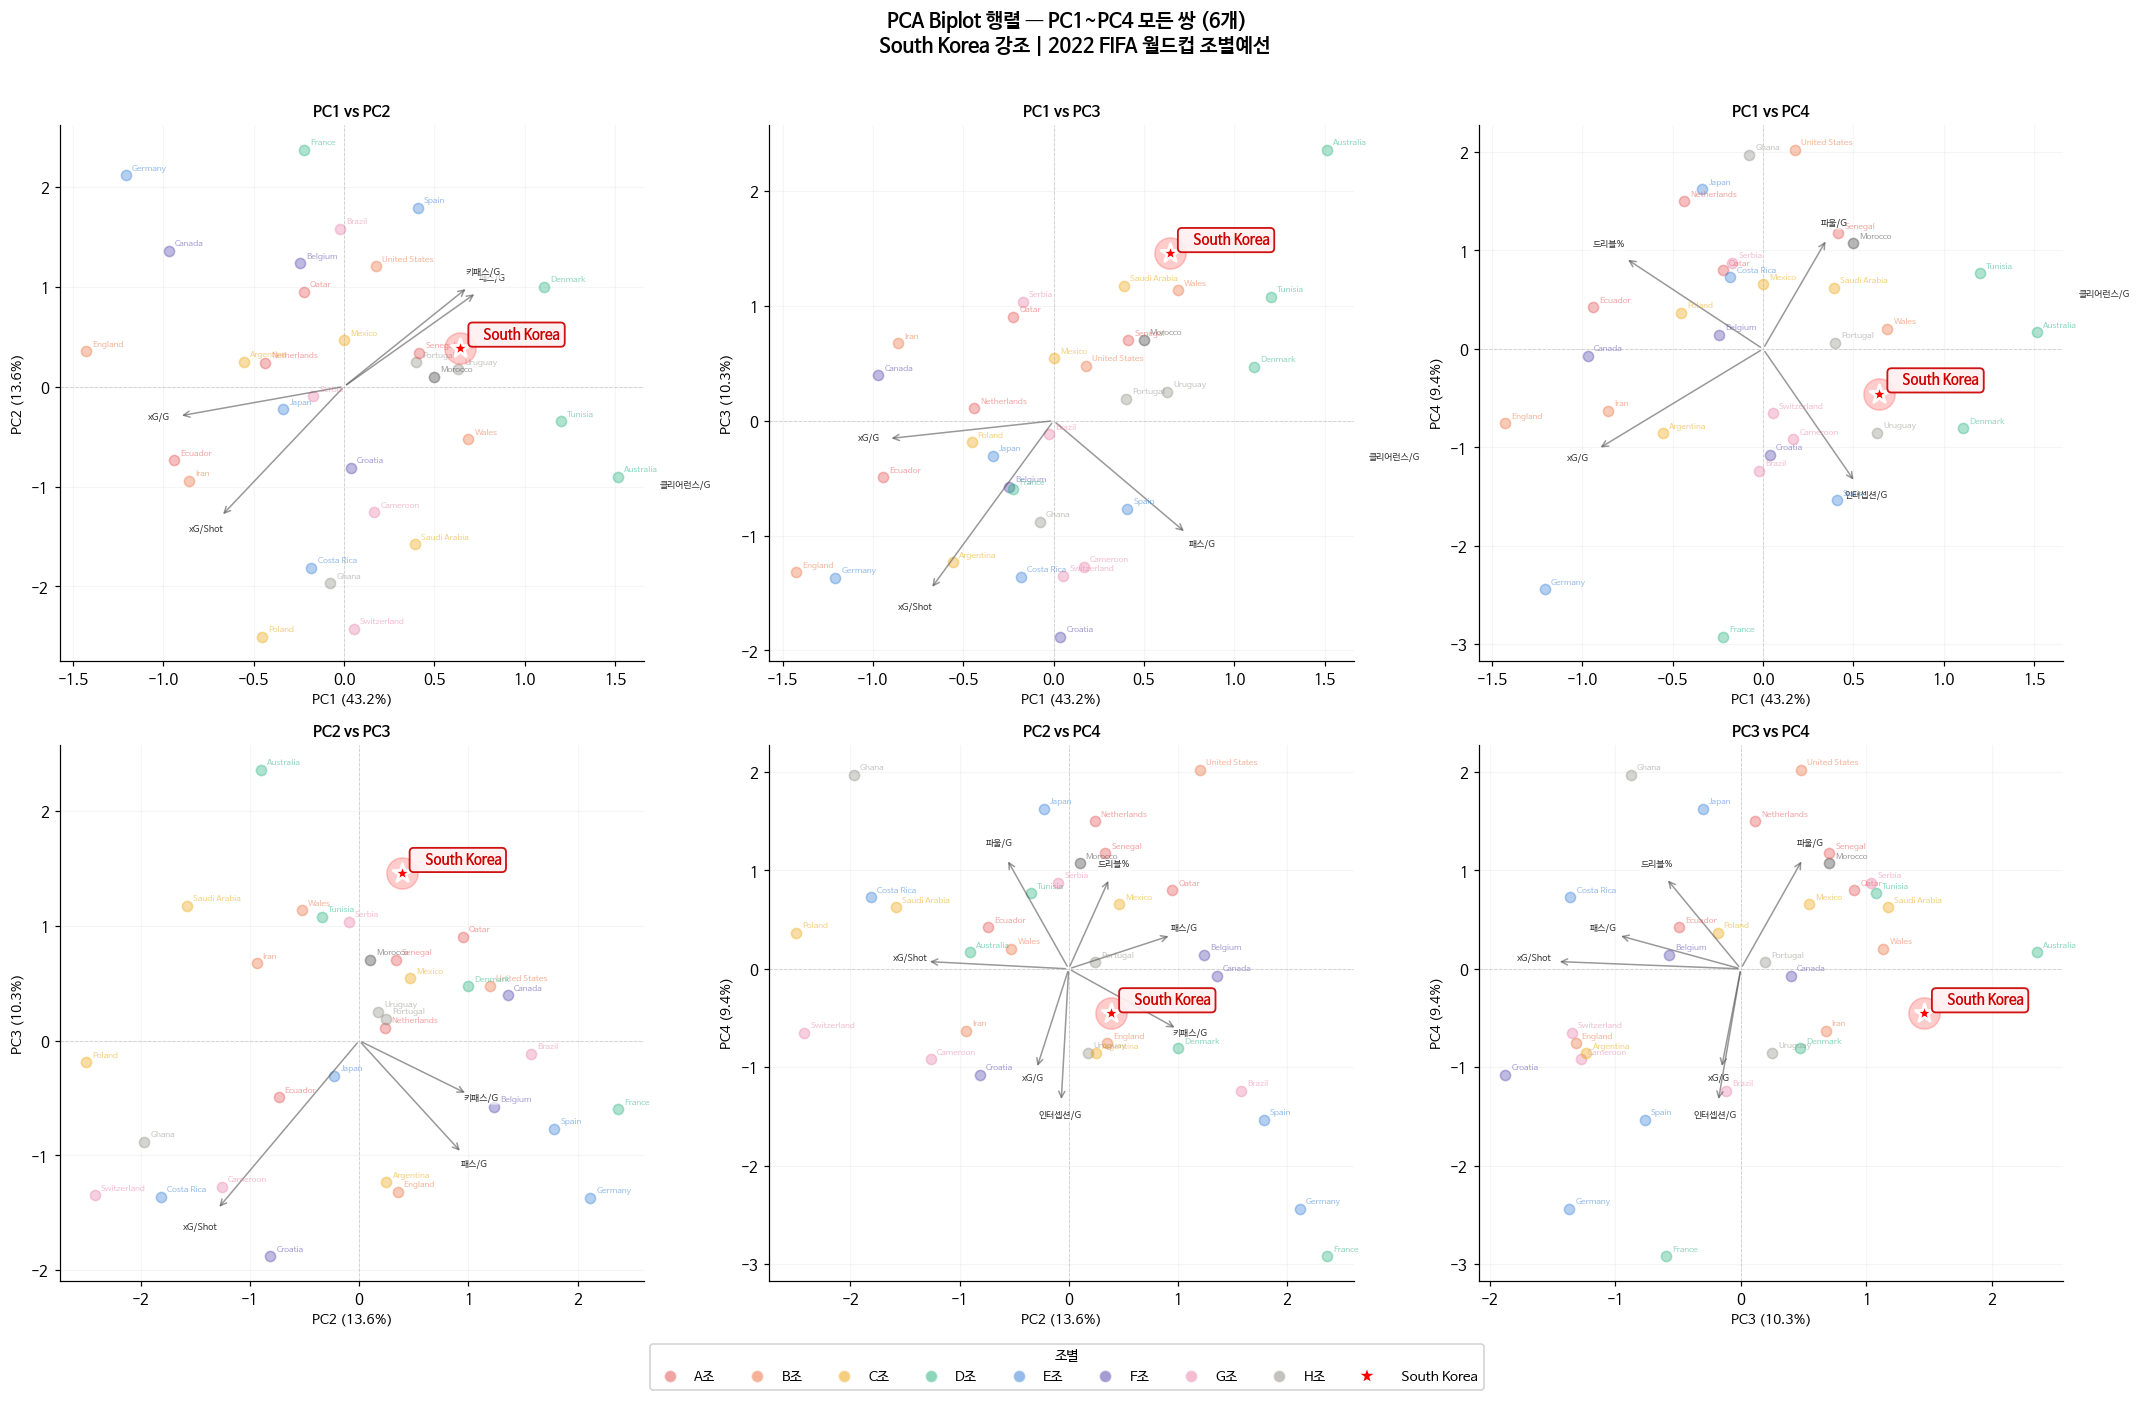

In [11]:
# ── PC 쌍별 Biplot 행렬 (PC1~PC4, 6개 조합) ─────────────
N_PCS    = 4
SCALE    = 2.6
THRESHOLD = 0.35
HIGHLIGHT = 'South Korea'

grp_color = {'A':'#e34948','B':'#eb6834','C':'#eda100','D':'#1baf7a',
             'E':'#2a78d6','F':'#4a3aa7','G':'#e87ba4','H':'#888780'}

pc_pairs = list(combinations(range(N_PCS), 2))  # (0,1),(0,2),...,(2,3)
n_cols   = 3
n_rows   = (len(pc_pairs) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6.5, n_rows*6.0))
fig.suptitle(f'PCA Biplot 행렬 — PC1~PC{N_PCS} 모든 쌍 ({len(pc_pairs)}개)\n'
             '🇰🇷 South Korea 강조 | 2022 FIFA 월드컵 조별예선',
             fontsize=13, fontweight='bold', y=1.01)

axes_flat  = axes.flatten()
teams_list = df_pca.index.tolist()

for ax_idx, (pc_a, pc_b) in enumerate(pc_pairs):
    ax = axes_flat[ax_idx]
    xa = scores[:, pc_a]
    ya = scores[:, pc_b]

    for i, team in enumerate(teams_list):
        is_kor = (team == HIGHLIGHT)
        grp    = df_pca.loc[team, 'group']
        color  = grp_color.get(grp, '#333')

        if is_kor:
            ax.scatter(xa[i], ya[i], color='#FF0000', s=420, zorder=5, alpha=0.20)
            ax.scatter(xa[i], ya[i], color='#FF0000', s=160, zorder=6,
                       edgecolors='white', linewidth=1.8, marker='*')
            ax.annotate('🇰🇷 ' + team, (xa[i], ya[i]),
                        textcoords='offset points', xytext=(8,6),
                        fontsize=9, color='#CC0000', fontweight='bold', zorder=7,
                        bbox=dict(boxstyle='round,pad=0.3', fc='#FFF0F0',
                                  ec='#CC0000', lw=1.2, alpha=0.92))
        else:
            ax.scatter(xa[i], ya[i], color=color, s=45, zorder=3, alpha=0.35)
            ax.annotate(team, (xa[i], ya[i]),
                        textcoords='offset points', xytext=(4,3),
                        fontsize=5.5, color=color, zorder=4, alpha=0.5)

    for j, name in enumerate(col_short):
        lx = V[j, pc_a] * SCALE
        ly = V[j, pc_b] * SCALE
        if max(abs(V[j, pc_a]), abs(V[j, pc_b])) < THRESHOLD:
            continue
        ax.annotate('', xy=(lx, ly), xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.0, alpha=0.6))
        ax.text(lx*1.12, ly*1.12, name, fontsize=6, ha='center', color='#333',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.7))

    ax.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.3)
    ax.axvline(0, color='gray', lw=0.6, ls='--', alpha=0.3)
    ax.set_xlabel(f'PC{pc_a+1} ({evr[pc_a]*100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC{pc_b+1} ({evr[pc_b]*100:.1f}%)', fontsize=9)
    ax.set_title(f'PC{pc_a+1} vs PC{pc_b+1}', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.12)

for ax_idx in range(len(pc_pairs), len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

fig.legend(
    handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
             markersize=8, label=f'{g}조', alpha=0.5) for g, c in grp_color.items()] +
            [Line2D([0],[0], marker='*', color='w', markerfacecolor='#FF0000',
             markersize=12, label='🇰🇷 South Korea')],
    loc='lower center', ncol=9, fontsize=9,
    title='조별', title_fontsize=9, framealpha=0.9,
    bbox_to_anchor=(0.5, -0.04)
)
plt.tight_layout()
plt.show()
